# 00 — Exploratory Data Analysis
Reads the raw dataset and produces all EDA figures and statistics.
> Run this notebook first.

In [2]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── All imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})
os.makedirs("data", exist_ok=True)


In [4]:
# ── Load raw data ─────────────────────────────────────────────────────────
df = pd.read_csv("Hotel_Reviews.csv")
df["days_since_review"] = (
    df["days_since_review"].astype(str).str.extract(r"(\d+)").astype(float))
df["Negative_Review"] = df["Negative_Review"].replace("No Negative", "")
df["Positive_Review"] = df["Positive_Review"].replace("No Positive", "")
df["combined_review"] = (
    df["Positive_Review"].fillna("") + " " + df["Negative_Review"].fillna("")
).str.strip()
df["Review_Date"] = pd.to_datetime(df["Review_Date"])
df_clean = df.dropna(subset=["lat", "lng", "Reviewer_Score"])
print(f"Clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(df_clean["Reviewer_Score"].describe().round(3))


Clean dataset: 512,470 rows × 18 columns
count    512470.000
mean          8.396
std           1.638
min           2.500
25%           7.500
50%           8.800
75%           9.600
max          10.000
Name: Reviewer_Score, dtype: float64


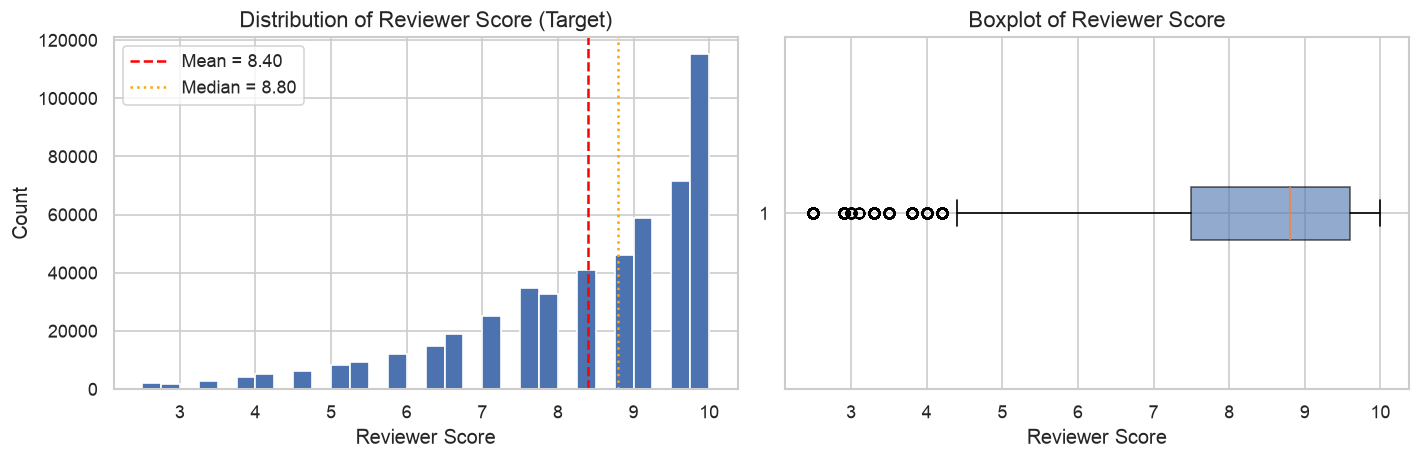

In [5]:
# ── Target distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean["Reviewer_Score"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(df_clean["Reviewer_Score"].mean(),   color="red",    linestyle="--",
                label=f"Mean = {df_clean['Reviewer_Score'].mean():.2f}")
axes[0].axvline(df_clean["Reviewer_Score"].median(), color="orange", linestyle=":",
                label=f"Median = {df_clean['Reviewer_Score'].median():.2f}")
axes[0].set_xlabel("Reviewer Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Reviewer Score (Target)"); axes[0].legend()
axes[1].boxplot(df_clean["Reviewer_Score"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[1].set_xlabel("Reviewer Score"); axes[1].set_title("Boxplot of Reviewer Score")
plt.tight_layout()
plt.savefig("data/fig_target_distribution.png", bbox_inches="tight", dpi=120)
plt.show()


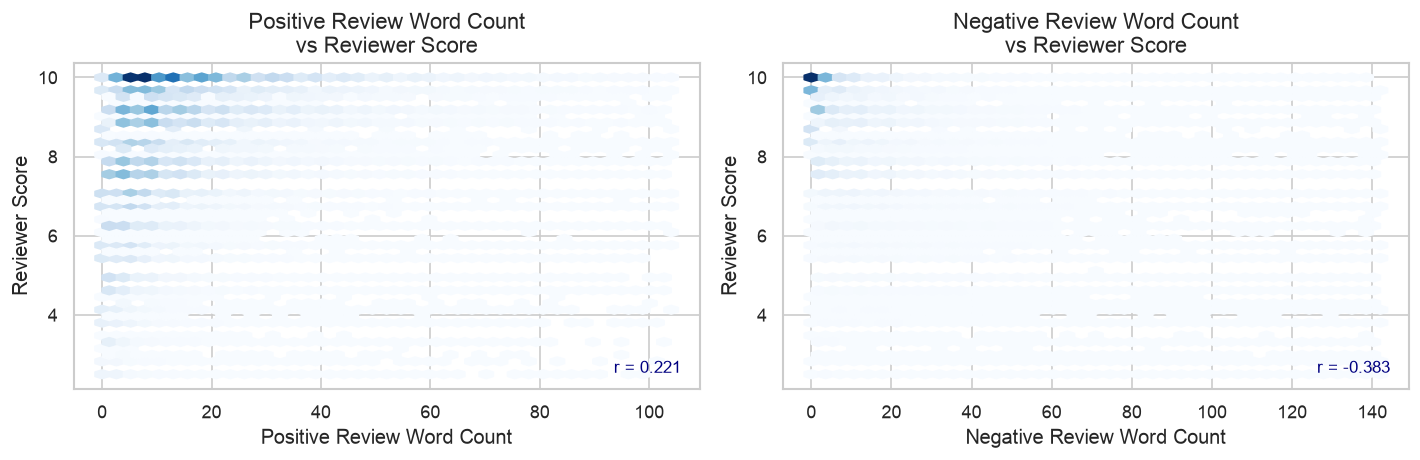

In [6]:
# ── Word count vs score hexbin ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes,
    ["Review_Total_Positive_Word_Counts", "Review_Total_Negative_Word_Counts"],
    ["Positive Review Word Count",        "Negative Review Word Count"]):
    cap = df_clean[col].quantile(0.99)
    sub = df_clean[df_clean[col] <= cap]
    ax.hexbin(sub[col], sub["Reviewer_Score"], gridsize=40, cmap="Blues", mincnt=1)
    ax.set_xlabel(label); ax.set_ylabel("Reviewer Score")
    ax.set_title(f"{label}\nvs Reviewer Score")
    r = df_clean[col].corr(df_clean["Reviewer_Score"])
    ax.annotate(f"r = {r:.3f}", xy=(0.97,0.05), xycoords="axes fraction",
                ha="right", fontsize=10, color="navy")
plt.tight_layout()
plt.savefig("data/fig_wordcount_vs_score.png", bbox_inches="tight", dpi=120)
plt.show()


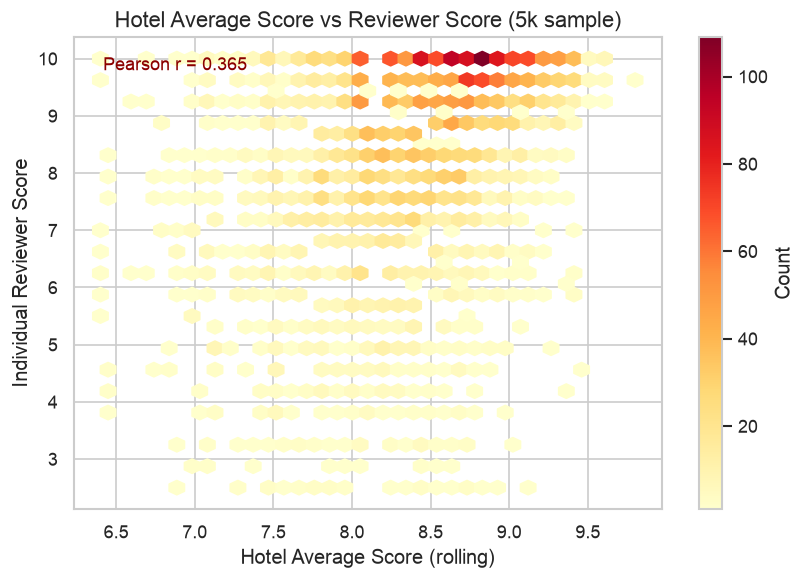

In [7]:
# ── Hotel average score vs reviewer score ────────────────────────────────
sample = df_clean.sample(5000, random_state=42)
plt.figure(figsize=(7,5))
hb = plt.hexbin(sample["Average_Score"], sample["Reviewer_Score"],
                gridsize=35, cmap="YlOrRd", mincnt=1)
plt.colorbar(hb, label="Count")
plt.xlabel("Hotel Average Score (rolling)"); plt.ylabel("Individual Reviewer Score")
plt.title("Hotel Average Score vs Reviewer Score (5k sample)")
r = df_clean["Average_Score"].corr(df_clean["Reviewer_Score"])
plt.annotate(f"Pearson r = {r:.3f}", xy=(0.05,0.93), xycoords="axes fraction",
             fontsize=11, color="darkred")
plt.tight_layout()
plt.savefig("data/fig_avg_vs_reviewer_score.png", bbox_inches="tight", dpi=120)
plt.show()


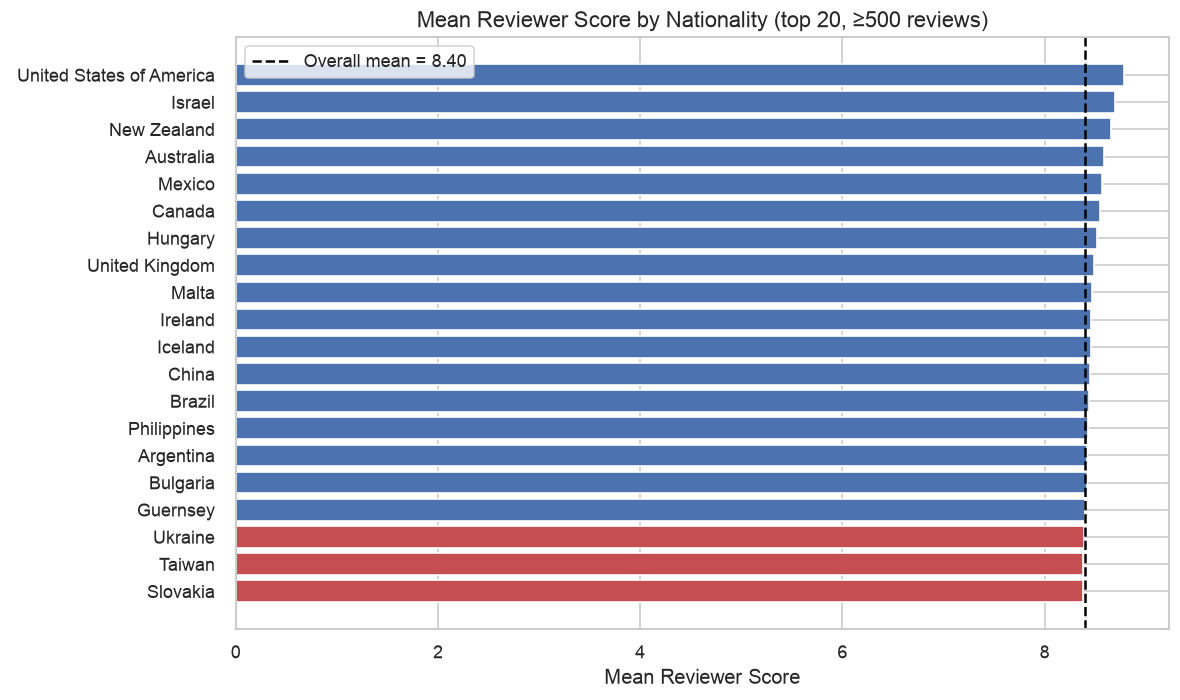

In [8]:
# ── Score by nationality ──────────────────────────────────────────────────
top_nat = (df_clean.groupby("Reviewer_Nationality")["Reviewer_Score"]
           .agg(["mean","count"]).query("count >= 500").sort_values("mean"))
fig, ax = plt.subplots(figsize=(10,6))
top_nat_plot = top_nat.tail(20)
overall_mean = df_clean["Reviewer_Score"].mean()
colors = ["#C44E52" if m < overall_mean else "#4C72B0" for m in top_nat_plot["mean"]]
ax.barh(top_nat_plot.index, top_nat_plot["mean"], color=colors)
ax.axvline(overall_mean, color="black", linestyle="--",
           label=f"Overall mean = {overall_mean:.2f}")
ax.set_xlabel("Mean Reviewer Score")
ax.set_title("Mean Reviewer Score by Nationality (top 20, ≥500 reviews)")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_nationality_scores.png", bbox_inches="tight", dpi=120)
plt.show()


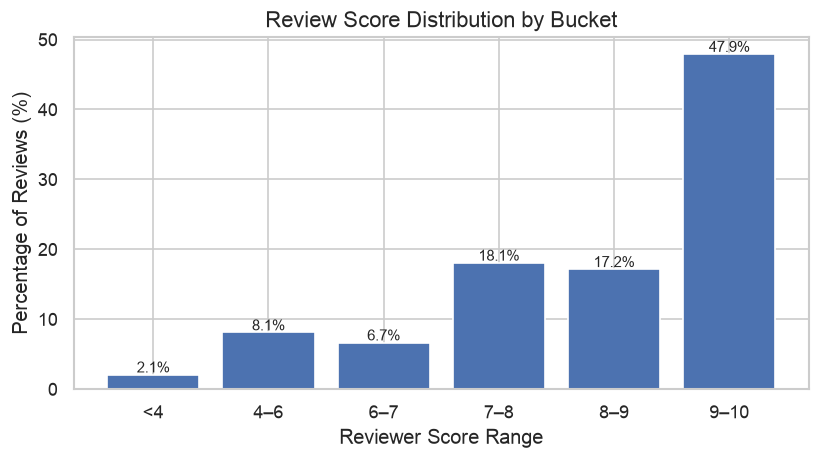

In [9]:
# ── Score bucket distribution ─────────────────────────────────────────────
bins   = [0,4,6,7,8,9,10.1]
labels = ["<4","4–6","6–7","7–8","8–9","9–10"]
df_clean["score_bucket"] = pd.cut(df_clean["Reviewer_Score"], bins=bins,
                                   labels=labels, right=False)
pct = df_clean["score_bucket"].value_counts(normalize=True).sort_index()*100
plt.figure(figsize=(7,4))
bars = plt.bar(pct.index.astype(str), pct.values, color="#4C72B0", edgecolor="white")
for i,v in enumerate(pct.values):
    plt.text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=9)
plt.xlabel("Reviewer Score Range"); plt.ylabel("Percentage of Reviews (%)")
plt.title("Review Score Distribution by Bucket")
plt.tight_layout()
plt.savefig("data/fig_score_buckets.png", bbox_inches="tight", dpi=120)
plt.show()


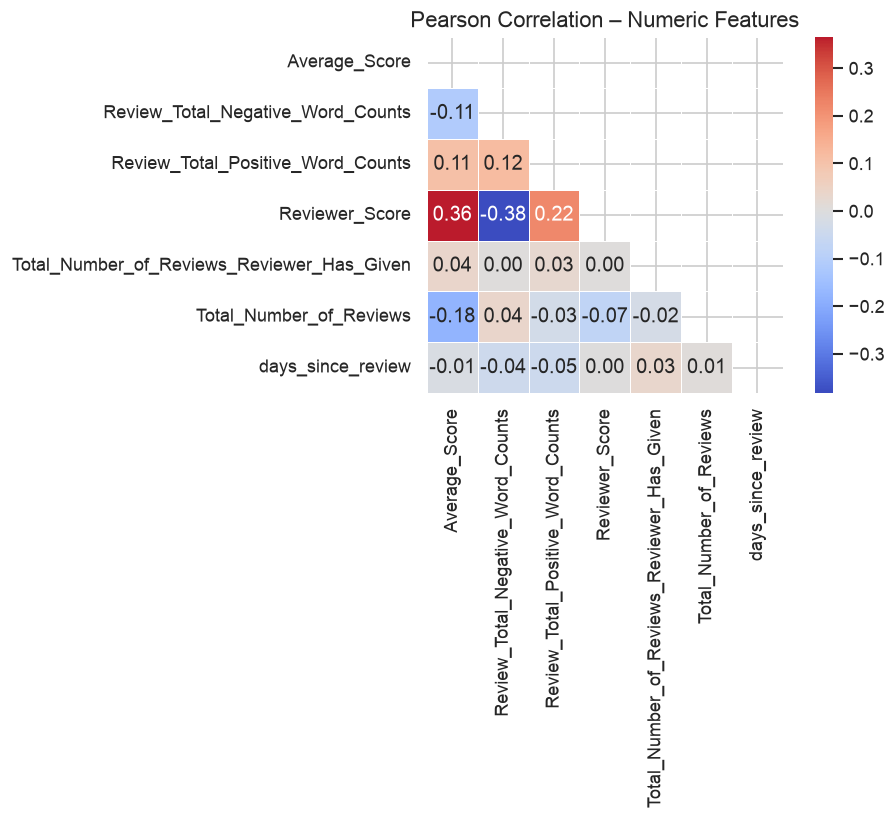

In [10]:
# ── Correlation heatmap ───────────────────────────────────────────────────
numeric_cols = ["Average_Score","Review_Total_Negative_Word_Counts",
                "Review_Total_Positive_Word_Counts","Reviewer_Score",
                "Total_Number_of_Reviews_Reviewer_Has_Given",
                "Total_Number_of_Reviews","days_since_review"]
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Pearson Correlation – Numeric Features")
plt.tight_layout()
plt.savefig("data/fig_correlation_heatmap.png", bbox_inches="tight", dpi=120)
plt.show()


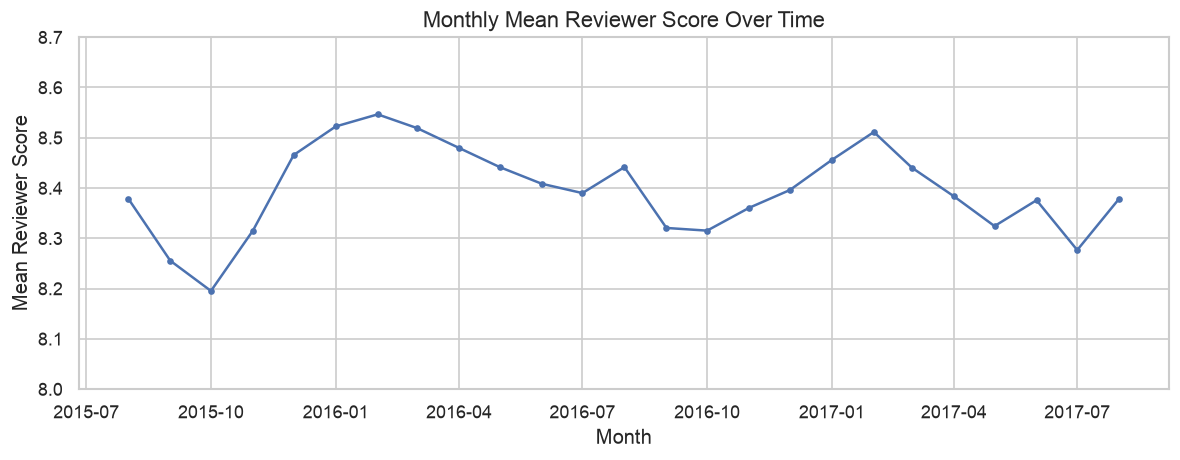

Score range over time: 8.195 – 8.547


In [11]:
# ── Time trend ───────────────────────────────────────────────────────────
monthly = df_clean.set_index("Review_Date")["Reviewer_Score"].resample("MS").mean()
plt.figure(figsize=(10,4))
plt.plot(monthly.index, monthly.values, marker="o", markersize=3,
         color="#4C72B0", linewidth=1.5)
plt.xlabel("Month"); plt.ylabel("Mean Reviewer Score")
plt.title("Monthly Mean Reviewer Score Over Time"); plt.ylim(8.0,8.7)
plt.tight_layout()
plt.savefig("data/fig_score_over_time.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"Score range over time: {monthly.min():.3f} – {monthly.max():.3f}")
